# Method Primer — Everything Used in the Production Sequencing Notebook

This notebook explains, one at a time, every pandas / numpy / matplotlib /
openpyxl method that shows up in the main training notebook. Nothing here is
about production sequencing — it's small, disconnected examples so you can
focus on *what each tool does* before seeing them combined into something more
complex.

**Run each cell, then change a number or argument and run it again.** That's
the fastest way to build a real feel for what each method does.

Sections, in the order you'll meet them in the main notebook:
1. NumPy — random generator and random choices
2. Pandas — building and inspecting a DataFrame
3. Pandas — selecting and editing specific rows
4. Pandas — running counts with `groupby` + `cumcount`
5. Pandas — looking at neighbors with `rolling` and `shift`
6. Matplotlib — basic plots (scatter, line, labels, legend)
7. Matplotlib — multiple plots in one figure
8. Pandas — shuffling rows and resetting the index
9. Pandas ↔ Excel — `read_excel` and `to_excel`
10. openpyxl — writing, saving, and reading a workbook directly
11. A few small Python patterns you'll see along the way


## 1. NumPy — random generator and random choices

`np.random.default_rng(seed)` creates a random number generator. Giving it a
seed number means "start from this exact random sequence" — so your results
are reproducible instead of different every time you run the cell.


In [2]:
import numpy as np

rng = np.random.default_rng(42)   # 42 is just a seed number, any integer works

# run this cell a few times: the numbers are the SAME every time,
# because the seed is fixed
print(rng.integers(0, 10, size=5))   # 5 random whole numbers from 0 up to (not including) 10


[0 7 6 4 4]


In [3]:
# now compare: a NEW generator with a different seed gives different numbers
rng2 = np.random.default_rng(999)
print(rng2.integers(0, 10, size=5))


[8 7 1 1 1]


`rng.choice(options, size=, p=probabilities)` picks randomly from a list of
options. `p` is optional — it lets you make some options more likely than
others (the probabilities must add up to 1.0).


In [4]:
fruits = ["apple", "banana", "cherry"]

# equal chance of each
print(rng.choice(fruits, size=8))

# banana much more likely than the other two
print(rng.choice(fruits, size=8, p=[0.1, 0.8, 0.1]))


['cherry' 'apple' 'cherry' 'apple' 'apple' 'banana' 'cherry' 'cherry']
['banana' 'banana' 'banana' 'banana' 'cherry' 'banana' 'banana' 'banana']


`rng.random()` gives one random decimal number between 0 and 1. This is
useful for "should this happen or not" decisions — e.g. "only do this 30% of
the time."


In [5]:
# roughly 30% of these should be True
results = [rng.random() < 0.3 for _ in range(10)]
print(results)
print("How many True:", sum(results))


[True, False, True, False, False, False, False, False, False, False]
How many True: 2


## 2. Pandas — building and inspecting a DataFrame

A DataFrame is a table. The easiest way to build one from scratch is a
dictionary where each key becomes a column.


In [6]:
import pandas as pd

df = pd.DataFrame({
    "id": [1, 2, 3, 4, 5],
    "color": ["red", "blue", "red", "green", "blue"],
})
df


,id,color
0,1,red
1,2,blue
2,3,red
3,4,green
4,5,blue


`.head(n)` shows just the first `n` rows — useful for big tables where you
don't want to print everything. `.dtypes` shows what type of data is in each
column (whole numbers, decimals, text, etc.) — helpful for spotting when a
column isn't the type you expected.


In [7]:
print(df.head(3))
print()
print(df.dtypes)


   id color
0   1   red
1   2  blue
2   3   red

id       int64
color      str
dtype: object


## 3. Pandas — selecting and editing specific rows

`.loc[row_label]` selects rows by their label (usually the same as position,
unless you've changed the index). You can pass a **list of labels** to select
several rows at once, and even to swap values between them.


In [8]:
df2 = pd.DataFrame({"id": [1, 2, 3], "color": ["red", "blue", "green"]})
print("before:")
print(df2)

# swap the "color" values of rows 0 and 2
df2.loc[[0, 2], "color"] = df2.loc[[2, 0], "color"].values
print()
print("after swapping rows 0 and 2:")
print(df2)


before:
   id  color
0   1    red
1   2   blue
2   3  green

after swapping rows 0 and 2:
   id  color
0   1  green
1   2   blue
2   3    red


Notice `.values` at the end — without it, pandas tries to match up row
labels while assigning, which undoes the swap. `.values` strips away the
labels and just gives the plain values in order, so the swap actually happens.
Try removing `.values` above and see what happens.


**Boolean masks** are how you select rows that match a condition, instead
of picking them by position. `df["col"] == value` gives you a column of
True/False, and using that inside `[...]` filters the rows.


In [9]:
mask = df2["color"] == "green"
print(mask)
print()
print(df2[mask])   # only the rows where mask is True


0     True
1    False
2    False
Name: color, dtype: bool

   id  color
0   1  green


`.index[mask].tolist()` is a common combo: it gives you the actual row
labels where the condition is True, as a plain Python list (instead of a
DataFrame).


In [10]:
matching_rows = df2.index[mask].tolist()
print(matching_rows)


[0]


`.copy()` makes an independent copy of a DataFrame. This matters because
without it, editing the copy would also silently edit the original — `.copy()`
protects against that.


In [11]:
original = pd.DataFrame({"x": [1, 2, 3]})
copy_of_it = original.copy()
copy_of_it.loc[0, "x"] = 999

print("original:", original["x"].tolist())      # unchanged
print("copy:", copy_of_it["x"].tolist())        # changed


original: [1, 2, 3]
copy: [999, 2, 3]


## 4. Pandas — running counts with `groupby` + `cumcount`

`.groupby("col")` groups rows that share the same value in `col`.
`.cumcount()` then counts, *within each group*, how many times that value has
appeared so far (starting at 0). Adding 1 makes it start at 1 instead.


In [12]:
df3 = pd.DataFrame({"job_type": ["A", "B", "A", "A", "B", "C"]})
df3["running_count"] = df3.groupby("job_type").cumcount() + 1
df3


,job_type,running_count
0,A,1
1,B,1
2,A,2
3,A,3
4,B,2
5,C,1


Read it row by row: the first "A" gets count 1, the second "A" gets count
2, the third gets 3 — but "B" and "C" have their own separate counts, because
`groupby` keeps each job_type's counting independent.


## 5. Pandas — looking at neighbors with `rolling` and `shift`

`.rolling(window=n)` looks at a "sliding window" of `n` rows at a time and
lets you compute something over each window — here, a sum.


In [15]:
s = pd.Series([1, 0, 1, 1, 0, 0, 1])
print("original:       ", s.tolist())
print("rolling sum(3): ", s.rolling(window=3, min_periods=1).sum().tolist())


original:        [1, 0, 1, 1, 0, 0, 1]
rolling sum(3):  [1.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.0]


Each output number is the sum of the current row and the 2 before it
(since window=3). `min_periods=1` means it still computes something even at
the very start, when there aren't 3 rows yet, instead of returning nothing.


`.shift(1)` moves every value down by one row — so each row can be
compared against the row *before* it. This is exactly how you detect "is this
the same as the previous row?"


In [16]:
s2 = pd.Series(["A", "A", "B", "B", "B", "C"])
print("original:      ", s2.tolist())
print("shifted by 1:  ", s2.shift(1).tolist())   # first value becomes empty (NaN)
print("same as prev?  ", (s2 == s2.shift(1)).tolist())


original:       ['A', 'A', 'B', 'B', 'B', 'C']
shifted by 1:   [nan, 'A', 'A', 'B', 'B', 'B']
same as prev?   [False, True, False, True, True, False]


## 6. Matplotlib — basic plots (scatter, line, labels, legend)

`plt.subplots()` creates a figure (the whole drawing area) and one or more
axes (the actual plot area) at once. For a single plot, you just get one of
each.


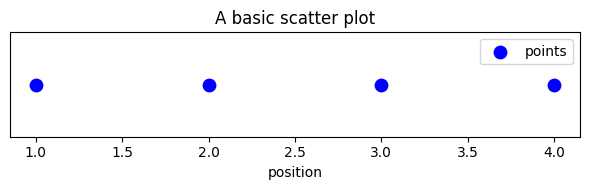

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 2))
ax.scatter([1, 2, 3, 4], [0, 0, 0, 0], color="blue", s=80, label="points")
ax.set_yticks([])                 # hide the y-axis numbers, they're meaningless here
ax.set_xlabel("position")
ax.set_title("A basic scatter plot")
ax.legend()
plt.tight_layout()                # tidies up spacing so labels don't get cut off
plt.show()


A line plot uses `plt.plot()` instead of `.scatter()` — good for showing
a value changing over time or over iterations.


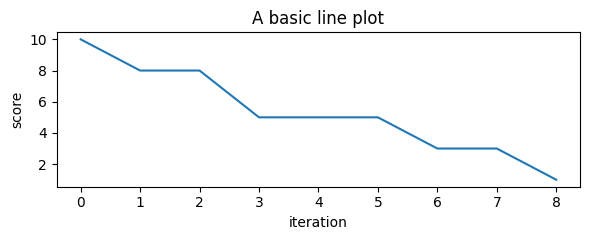

In [18]:
values_over_time = [10, 8, 8, 5, 5, 5, 3, 3, 1]

plt.figure(figsize=(6, 2.5))
plt.plot(values_over_time)
plt.xlabel("iteration")
plt.ylabel("score")
plt.title("A basic line plot")
plt.tight_layout()
plt.show()


## 7. Matplotlib — multiple plots in one figure

`plt.subplots(rows, cols)` creates a *grid* of plots at once. With
`sharex=True`, all plots in the grid line up on the same x-axis — useful when
you want to compare two things over the same iterations, stacked vertically.


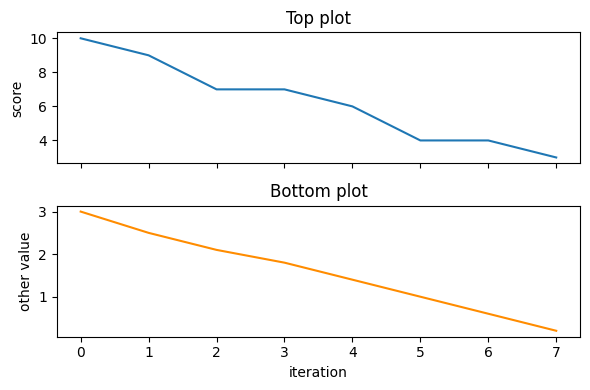

In [19]:
scores = [10, 9, 7, 7, 6, 4, 4, 3]
some_other_value = [3.0, 2.5, 2.1, 1.8, 1.4, 1.0, 0.6, 0.2]

fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

axes[0].plot(scores)
axes[0].set_ylabel("score")
axes[0].set_title("Top plot")

axes[1].plot(some_other_value, color="darkorange")
axes[1].set_ylabel("other value")
axes[1].set_xlabel("iteration")
axes[1].set_title("Bottom plot")

plt.tight_layout()
plt.show()


`axes` here is just a list — `axes[0]` is the top plot, `axes[1]` is the
bottom one. That's why you can call `.plot()`, `.set_title()`, etc. on each
one separately.


## 8. Pandas — shuffling rows and resetting the index

`.sample(frac=1)` returns *all* rows (`frac=1` means 100%) but in random
order — a common trick for shuffling a DataFrame. `random_state=` works like
numpy's seed: same number, same shuffle, every time.


In [20]:
df4 = pd.DataFrame({"id": [1, 2, 3, 4, 5]})
shuffled = df4.sample(frac=1, random_state=1)
print(shuffled)


   id
2   3
1   2
4   5
0   1
3   4


Notice the row **labels** (the bold numbers on the left) stayed with
their original rows after shuffling — only the order changed. `.reset_index(drop=True)`
renumbers the labels 0, 1, 2, ... to match the new order, and `drop=True`
throws away the old labels instead of keeping them as a column.


In [21]:
shuffled_clean = shuffled.reset_index(drop=True)
print(shuffled_clean)


   id
0   3
1   2
2   5
3   1
4   4


## 9. Pandas ↔ Excel — `read_excel` and `to_excel`

`pd.read_excel(path)` reads a spreadsheet straight into a DataFrame.
`DataFrame.to_excel(path, index=False)` writes a DataFrame back out to a new
spreadsheet file. `index=False` stops pandas from adding an extra unwanted
column with the row labels.


In [24]:
demo_df = pd.DataFrame({"id": [1, 2, 3], "value": [10, 20, 30]})

demo_path = "primer_demo.xlsx"
demo_df.to_excel(demo_path, index=False)

loaded_back = pd.read_excel(demo_path)
print(loaded_back)


   id  value
0   1     10
1   2     20
2   3     30


**Important limitation to remember for later:** `to_excel()` only knows
about plain values. If the original file had an Excel *formula* in a column,
`to_excel()` cannot preserve it — it can only write whatever plain value
pandas currently has in memory. That's the exact problem the main training
notebook demonstrates and works around using `openpyxl` directly.


## 10. openpyxl — writing, saving, and reading a workbook directly

`openpyxl` works at a lower level than pandas: instead of a whole table at
once, you work cell by cell, which is what lets you preserve formulas.

`openpyxl.Workbook()` creates a new, empty workbook. `wb.active` gives you its
first (currently only) sheet.


In [25]:
import openpyxl

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "my_sheet"

# write to individual cells using Excel-style addresses
ws["A1"] = "name"
ws["B1"] = "score"
ws["A2"] = "Alice"
ws["B2"] = 95

wb.save("primer_demo2.xlsx")
print("saved")


saved


A cell can also hold a **formula** — you just write it as a text string
starting with `=`, exactly as you'd type it in Excel.


In [ ]:
ws["C1"] = "double_score_formula"
ws["C2"] = "=B2*2"   # a real Excel formula, not a computed number

wb.save("primer_demo2.xlsx")
print("saved with a formula in C2")


saved with a formula in C2


`openpyxl.load_workbook(path)` opens an existing file so you can read or
edit it. Reading `ws["C2"].value` gives you back the **formula text itself**
(`=B2*2`), not the calculated result — openpyxl doesn't calculate formulas,
it just stores and reads them exactly as Excel would store them.


In [ ]:
check_wb = openpyxl.load_workbook("primer_demo2.xlsx")
check_ws = check_wb.active
print("A2:", check_ws["A2"].value)
print("B2:", check_ws["B2"].value)
print("C2:", check_ws["C2"].value)   # the formula text, not a computed number


A2: Alice
B2: 95
C2: =B2*2


`get_column_letter(n)` converts a column *number* (1, 2, 3, ...) into its
Excel *letter* (A, B, C, ...). Handy when you're building cell addresses like
`f"{letter}{row_number}"` in a loop instead of typing them by hand.


In [23]:
from openpyxl.utils import get_column_letter

for n in [1, 2, 3, 26, 27]:
    print(n, "->", get_column_letter(n))


1 -> A
2 -> B
3 -> C
26 -> Z
27 -> AA


## 11. A few small Python patterns you'll see along the way

These aren't new methods, just habits that show up repeatedly in the main
notebook.


**f-strings** — the `f` before a string lets you drop variables directly
inside `{ }`, instead of gluing pieces of text together manually.


In [24]:
name = "Alice"
score = 95
print(f"{name} scored {score} points")


Alice scored 95 points


**Dictionary comprehension** — a compact way to build a dictionary from a
list, in one line.


In [25]:
columns = ["id", "job_type", "score"]
letters = {name: get_column_letter(i + 1) for i, name in enumerate(columns)}
print(letters)


{'id': 'A', 'job_type': 'B', 'score': 'C'}


**`enumerate(list, start=1)`** — loops over a list while also giving you a
counter, starting from whatever number you choose (often 1 instead of the
default 0).


In [26]:
items = ["first", "second", "third"]
for position, item in enumerate(items, start=1):
    print(position, item)


1 first
2 second
3 third


**Set union with `|`** — combines two sets, automatically removing
duplicates. Useful for merging "violating rows from rule 1" with "violating
rows from rule 2" into one list with no repeats.


In [27]:
rows_from_rule_1 = {2, 4, 6}
rows_from_rule_2 = {4, 5, 6}
combined = sorted(rows_from_rule_1 | rows_from_rule_2)
print(combined)


[2, 4, 5, 6]


---

## You're ready

Every method used in the main **Production Sequencing Training Notebook** has
now been shown in isolation. When you see them again there — combined into
real rules, a search loop, and safe Excel writing — nothing about the *syntax*
should be new. The only new thing will be *how they're combined* to solve the
actual problem, which is exactly what that notebook is for.
